In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

In [3]:
def parse_data_file(filename):
    # Чтение файла и парсинг данных по каналам без сохранения во временные csv
    with open(filename, "r") as raw_data:
        channel_data = {}
        headers = {}
        channel_order = []
        while True:
            line = raw_data.readline()
            if not line:
                break
            if line.startswith("#CHANNEL"):
                ch = line.split(":")[1].strip()
                channel_order.append(ch)
                size_line = raw_data.readline()
                size = int(size_line.strip().split('=')[1])
                header_line = raw_data.readline().strip().split(",")
                headers[ch] = header_line
                channel_data[ch] = []
                for i in range(size):
                    data_line = raw_data.readline().strip().split(",")
                    channel_data[ch].append(data_line)
    # Преобразуем данные каналов в DataFrame
    dfs = {}
    for ch in channel_order:
        dfs[ch] = pd.DataFrame(channel_data[ch], columns=headers[ch])
        for col in dfs[ch].columns:
            dfs[ch][col] = pd.to_numeric(dfs[ch][col], errors='coerce')
    # Собираем итоговый DataFrame
    data = pd.DataFrame()
    # Предполагаем, что первый канал содержит время
    time_col = None
    for col in dfs[channel_order[0]].columns:
        if "Time" in col:
            time_col = col
            break
    if time_col is None:
        raise ValueError("Не найден столбец времени в первом канале")
    data["Time, s"] = dfs[channel_order[0]][time_col]
    # Добавляем все каналы
    for idx, ch in enumerate(channel_order):
        volt_col = None
        for col in dfs[ch].columns:
            if "Volt" in col:
                volt_col = col
                break
        if volt_col is not None:
            data[f"V_{idx+1}"] = dfs[ch][volt_col]
    return data


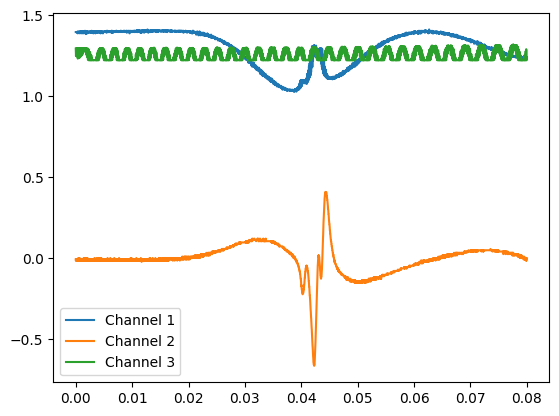

In [10]:
data_1 = parse_data_file("85_F3_SD.txt")
plt.plot(data_1["Time, s"], data_1["V_1"], label="Channel 1")
plt.plot(data_1["Time, s"], data_1["V_2"], label="Channel 2")
plt.plot(data_1["Time, s"], data_1["V_3"], label="Channel 3")
#plt.plot(data_1["Time, s"], data_1["V_4"], label="Channel 1")
plt.legend()

74.9481145 MHz


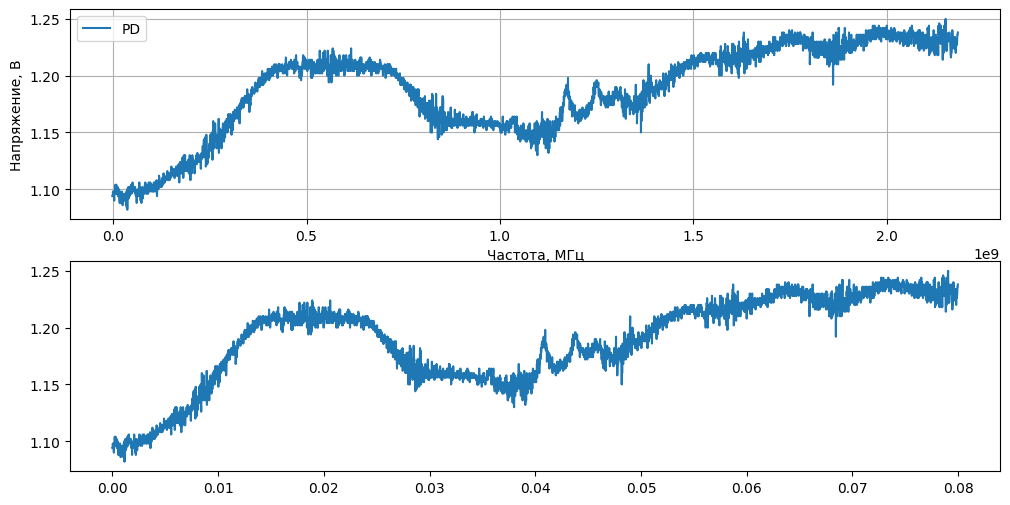

In [107]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt


c = 299792458
a = 1
dnu = c/(4*a)
print(dnu*1E-6, 'MHz') # частоты между пиками интерферометра


def find_peaks_and_make_nu(data):
    x = data["Time, s"]
    y = data["Interferometer"]
    
    # Находим пики (локальные максимумы)
    peaks, properties = sp.signal.find_peaks(
        np.array(y),   
        distance=10,          # минимум 10 точек между пиками
        prominence=0.005,     # минимальная "выдающаяся" высота
        width=1
    )

    # Визуализируем результат
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x, y, 'b-', linewidth=1, label='Исходная кривая')
    ax.plot(np.array(x)[peaks], np.array(y)[peaks], "rx", 
            markersize=8, markeredgewidth=2, label='Найденные пики')
    
    # Расчет расстояний между пиками
    peaks_x = np.array(x)[peaks]
    distances = np.diff(peaks_x)  # более элегантный способ
    
    # Добавляем информацию о расстояниях на график
    for i in range(len(peaks_x)-1):
        mid_x = (peaks_x[i] + peaks_x[i+1]) / 2
        mid_y = (np.array(y)[peaks[i]] + np.array(y)[peaks[i+1]]) / 2
        ax.annotate(f'{distances[i]*10000:.2f}', 
                   xy=(mid_x, mid_y), 
                   xytext=(0, 10), 
                   textcoords='offset points',
                   ha='center', fontsize=8, color='green')
    
    # # Вывод отладочной информации
    # print(f"Всего найдено пиков: {len(peaks)}")
    # print(f"Первые 5 расстояний (x10000): {distances[:5]*10000}")
    # print(f"Последние 5 расстояний (x10000): {distances[-5:]*10000}")
    
    # # Статистика
    # print(f"\nСтатистика расстояний:")
    # print(f"  Среднее: {np.mean(distances)*10000:.2f}")
    # print(f"  Std: {np.std(distances)*10000:.2f}")
    # print(f"  Мин: {np.min(distances)*10000:.2f}")
    # print(f"  Макс: {np.max(distances)*10000:.2f}")
    
    # Оформление графика
    ax.set_xlabel("Time, s", fontsize=12)
    ax.set_ylabel("$V_{интерферометра}$, В", fontsize=12)
    ax.set_title(f"Найденные пики (всего: {len(peaks)})", fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # plt.tight_layout()
    # plt.show()
    
    return peaks_x, distances, fig


def data_parse(file_name):
    raw_data = parse_data_file(file_name)
    data = pd.DataFrame()
    data["Time, s"] = raw_data["Time, s"]
    data["Interferometer"] = raw_data["V_3"]
    data["PD"] = raw_data["V_1"]
    b, a = sp.signal.butter(3, [0.01,100000], btype='band', fs=1000000)
    data["Interferometer"] = sp.signal.filtfilt(b, a, data["Interferometer"])
    peaks_x, distances, fig_peaks = find_peaks_and_make_nu(data)
    def delta_nu(t):
        if t < peaks_x[0]:
            # Extrapolate using first interval
            dt = peaks_x[1] - peaks_x[0]
            fraction = (t - peaks_x[0]) / dt
            return dnu * fraction
        elif t > peaks_x[-1]:
            # Extrapolate using last interval
            dt = peaks_x[-1] - peaks_x[-2]
            fraction = (t - peaks_x[-1]) / dt
            return dnu * (len(peaks_x) - 1 + fraction)
        else:
            # Original logic
            i = len(peaks_x[peaks_x < t]) - 1
            fraction = (t - peaks_x[i]) / (peaks_x[i+1] - peaks_x[i])
            return dnu * (i + fraction)
    
    
    data["nu"] = data["Time, s"].apply(delta_nu)
    
    fig_PD, (ax_PD, ax_PD_2) = plt.subplots(2, 1, figsize=(12, 6))
    ax_PD.plot(data["nu"], data["PD"], label="PD")
    ax_PD_2.plot(data["Time, s"], data["PD"], label="PD")
    ax_PD.set_xlabel("Частота, МГц")
    ax_PD.set_ylabel("Напряжение, В")
    ax_PD.legend()
    ax_PD.grid()
    display(fig_PD)

data_parse("87f2.txt")